In [ ]:
#Import

In [1]:
import numpy as np
import pandas as pd

df = pd.read_csv('./cleaned_cyberbullying_tweets.csv')
df['sentiment_encoded'].value_counts()

sentiment_encoded
5    7888
0    7808
1    7697
2    7318
3    6315
Name: count, dtype: int64

In [ ]:
##First Few Row Data

In [2]:
df.head()

,text_clean,sentiment_encoded
0,word katandandre food crapilicious mkr,3
1,aussietv white mkr theblock imacelebrityau tod...,3
2,classy whore red velvet cupcake,3
3,meh thanks head concerned another angry dude t...,3
4,isi account pretending kurdish account like is...,3


In [ ]:
## Model Training

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC  # Use LinearSVC instead of RandomForestClassifier
from sklearn.pipeline import Pipeline
import joblib

# Define the input and target variables
X = df['text_clean']
y = df['sentiment_encoded']

# Split the data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create a pipeline that first vectorizes the text and then applies the Linear SVM classifier
pipeline = Pipeline([
    ('tfidf', TfidfVectorizer()),  # Converts text to TF-IDF features
    ('svm', LinearSVC(random_state=42, dual='auto'))  # Linear SVM classifier
])

# Train the model
pipeline.fit(X_train, y_train)

# Make predictions on the test set
y_pred = pipeline.predict(X_test)

# Save the trained model using joblib
joblib.dump(pipeline, 'linear_svm.pkl')

['linear_svm.pkl']

In [ ]:
##Hyperparameter Tuning

In [17]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from scipy.stats import randint as sp_randint
from sklearn.svm import LinearSVC
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
import joblib

# Define the parameter grid for GridSearchCV
param_grid = {
    'tfidf__max_df': [0.7, 0.8, 0.9, 1.0],
    'tfidf__min_df': [1, 2, 5],
    'tfidf__ngram_range': [(1, 1), (1, 2)],
    'svm__C': [0.1, 1, 10, 100],  # Tuning C for LinearSVC
    'svm__max_iter': [1000, 2000, 3000]  # Tuning max_iter for LinearSVC
}

# Set up GridSearchCV
grid_search = GridSearchCV(
    pipeline,          # our previously defined pipeline
    param_grid,        # hyperparameters to tune
    cv=5,              # 5-fold cross-validation
    n_jobs=-1,         # use all available cores
    verbose=1
)

# Define the pipeline with LinearSVC instead of Random Forest
pipeline = Pipeline([
    ('tfidf', TfidfVectorizer()),  # Converts text to TF-IDF features
    ('svm', LinearSVC(random_state=42))  # Linear SVM classifier
])

# Fit GridSearchCV to the training data
grid_search.fit(X_train, y_train)
print("Best parameters from GridSearchCV:", grid_search.best_params_)
print("Best cross-validation score (GridSearchCV):", grid_search.best_score_)

# Define parameter distributions for RandomizedSearchCV
param_dist = {
    'tfidf__max_df': [0.7, 0.8, 0.9, 1.0],
    'tfidf__min_df': sp_randint(1, 10),
    'tfidf__ngram_range': [(1, 1), (1, 2)],
    'svm__C': sp_randint(1, 100),  # Tuning C for LinearSVC
    'svm__max_iter': [1000, 2000, 3000]  # Tuning max_iter for LinearSVC
}

# Set up RandomizedSearchCV
random_search = RandomizedSearchCV(
    pipeline,
    param_distributions=param_dist,
    n_iter=20,         # number of parameter settings sampled
    cv=5,              # 5-fold cross-validation
    n_jobs=-1,
    verbose=1,
    random_state=42
)

# Fit RandomizedSearchCV to the training data
random_search.fit(X_train, y_train)
print("Best parameters from RandomizedSearchCV:", random_search.best_params_)
print("Best cross-validation score (RandomizedSearchCV):", random_search.best_score_)

# Optionally, save the best model (from either search) for future use
# For example, using the grid search best estimator:
joblib.dump(grid_search.best_estimator_, 'linear_svm_best_grid.pkl')
# Or for the randomized search best estimator:
joblib.dump(random_search.best_estimator_, 'linear_svm_best_random.pkl')


Fitting 5 folds for each of 288 candidates, totalling 1440 fits


C:\Users\FYIHEN\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\svm\_classes.py:31: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(


Best parameters from GridSearchCV: {'svm__C': 1, 'svm__max_iter': 1000, 'tfidf__max_df': 0.7, 'tfidf__min_df': 2, 'tfidf__ngram_range': (1, 2)}
Best cross-validation score (GridSearchCV): 0.9297096556380824
Fitting 5 folds for each of 20 candidates, totalling 100 fits


C:\Users\FYIHEN\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\svm\_classes.py:31: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(


Best parameters from RandomizedSearchCV: {'svm__C': 4, 'svm__max_iter': 1000, 'tfidf__max_df': 1.0, 'tfidf__min_df': 2, 'tfidf__ngram_range': (1, 2)}
Best cross-validation score (RandomizedSearchCV): 0.9261309925725861


['linear_svm_best_random.pkl']

In [7]:
# Load the saved model from file
loaded_model = joblib.load('linear_svm.pkl')

In [ ]:
##Classification Report

In [8]:
from sklearn.metrics import classification_report


# Assuming X_test and y_test are already defined in your environment:
y_pred = loaded_model.predict(X_test)

# Generate and print the classification report
print("Classification Report:")
print(classification_report(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.98      0.96      1552
           1       0.98      0.99      0.98      1538
           2       0.93      0.89      0.91      1459
           3       0.81      0.82      0.82      1291
           5       0.95      0.95      0.95      1566

    accuracy                           0.93      7406
   macro avg       0.93      0.93      0.93      7406
weighted avg       0.93      0.93      0.93      7406


In [ ]:
## Confusion Matrix

Confusion Matrix:
[[1520    0    7   23    2]
 [   2 1516    2   16    2]
 [   4    9 1303  134    9]
 [  76   18   76 1064   57]
 [   2    3    7   72 1482]]


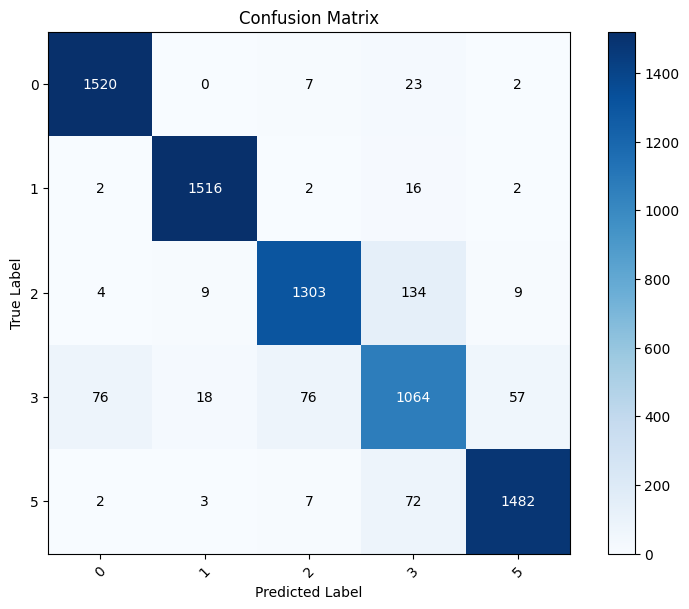

In [9]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

# Generate and print the confusion matrix
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
classes = np.unique(y_test)

plt.figure(figsize=(8, 6))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.colorbar()

tick_marks = np.arange(len(classes))
plt.xticks(tick_marks, classes, rotation=45)
plt.yticks(tick_marks, classes)

# Annotate each cell with its value
thresh = cm.max() / 2.
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, format(cm[i, j], 'd'),
                 ha='center', va='center',
                 color='white' if cm[i, j] > thresh else 'black')

plt.tight_layout()
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [ ]:
##Cross Validation Result

In [10]:
from sklearn.model_selection import cross_val_score

# If you have your full dataset (X and y) available, perform cross-validation
cv_scores = cross_val_score(loaded_model, X, y, cv=5)
print("Cross Validation Scores:")
print(cv_scores)
print("Mean Cross Validation Score:", cv_scores.mean())


Cross Validation Scores:
[0.9337024  0.93031735 0.92680621 0.92842674 0.9304524 ]
Mean Cross Validation Score: 0.9299410208668885


In [ ]:
## Accuracy Score 

In [11]:
from sklearn.metrics import accuracy_score

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")


Accuracy: 0.9297


In [ ]:
## Prediction 

In [13]:
import joblib

# 1. Load the saved model
loaded_model = joblib.load('linear_svm.pkl')

# 2. Define a new piece of text to classify
new_text = "The service was terrible, I am never coming back."

# 3. Predict the sentiment
prediction = loaded_model.predict([new_text])

# 4. Print the result
print(f"Text: {new_text}")
print(f"Predicted Sentiment: {prediction[0]}")

Text: The service was terrible, I am never coming back.
Predicted Sentiment: 3


In [16]:
import joblib

# 1. Load the saved model
loaded_model = joblib.load('linear_svm.pkl')

# 2. Define a new piece of text to classify
new_text = "you are the son of mother"

# 3. Predict the sentiment
prediction = loaded_model.predict([new_text])

# 4. Print the result
print(f"Text: {new_text}")
print(f"Predicted Sentiment: {prediction[0]}")

Text: you are the son of mother
Predicted Sentiment: 3
